In [22]:
## 0. Environment & Data Setup

In [23]:
from pathlib import Path
import os

IN_COLAB = Path("/content").exists()

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DATA_ROOT = Path(
        "/content/drive/MyDrive/MT-Hackathon-2026/data"
    )
else:
    # notebook находится в ml/notebooks/
    DATA_ROOT = Path("../../data").resolve()

print("Environment:", "Colab" if IN_COLAB else "Local")
print("DATA_ROOT:", DATA_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment: Colab
DATA_ROOT: /content/drive/MyDrive/MT-Hackathon-2026/data


In [24]:
PROCESSED_DIR = DATA_ROOT / "processed"
LABELS_DIR = DATA_ROOT / "labels"

TRAIN_HOURLY_PATH = PROCESSED_DIR / "baseline_train_hourly.csv"
VALID_HOURLY_PATH = PROCESSED_DIR / "baseline_validation_hourly.csv"

LABELS_TRAIN_PATH = LABELS_DIR / "labels_day_train.csv"
LABELS_TEST_PATH = LABELS_DIR / "labels_day_test.csv"

In [25]:
paths = [
    TRAIN_HOURLY_PATH,
    VALID_HOURLY_PATH,
    LABELS_TRAIN_PATH,
    LABELS_TEST_PATH,
]

for path in paths:
    print(path, "->", path.exists())

/content/drive/MyDrive/MT-Hackathon-2026/data/processed/baseline_train_hourly.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/processed/baseline_validation_hourly.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/labels/labels_day_train.csv -> True
/content/drive/MyDrive/MT-Hackathon-2026/data/labels/labels_day_test.csv -> True


In [26]:
import pandas as pd

train_hourly = pd.read_csv(TRAIN_HOURLY_PATH)
valid_hourly = pd.read_csv(VALID_HOURLY_PATH)

labels_train = pd.read_csv(LABELS_TRAIN_PATH)
labels_test = pd.read_csv(LABELS_TEST_PATH)

In [27]:
print("train_hourly:", train_hourly.shape)
print("valid_hourly:", valid_hourly.shape)
print("labels_train:", labels_train.shape)
print("labels_test:", labels_test.shape)

display(train_hourly.head())

train_hourly: (58320, 1)
valid_hourly: (14640, 1)
labels_train: (46234, 1)
labels_test: (11317, 1)


,route;date;hour;boardings
0,1;2025-01-01;0;0
1,1;2025-01-01;1;0
2,1;2025-01-01;2;0
3,1;2025-01-01;3;0
4,1;2025-01-01;4;0


**ВАЖНО:**
**Ниже не указывайте абсолютные пути Colab/Google Drive.**
**Используйте DATA_ROOT, переменные *_PATH или уже загруженные DataFrames.**

## 1. Frozen LightGBM baseline

Эта секция воспроизводит текущий baseline из `ml/src/lightgbm_baseline.py` и служит неизменяемым эталоном для последующих feature experiments.

| Параметр | Зафиксированный эталон |
|---|---|
| Целевая переменная / единица | `boardings` на `(route, date, hour)` |
| Обучение | январь–август 2025, 58 320 часовых строк |
| Временная валидация | сентябрь–октябрь 2025, непрерывный holdout, 14 640 строк |
| Признаки baseline | `route`, `weekday`, `hour` |
| Предобработка | все три признаки — `pandas.Categorical`; категории: маршруты `(1, 5, 7, 11, 12, 17, 25, 26, 28, 50)`, weekday `0…6`, hour `0…23` |
| LightGBM | `objective="regression_l1"`, `n_estimators=300`, `max_depth=6`, `num_leaves=31`, `learning_rate=0.1`, `random_state=42`, `n_jobs=4`, `verbosity=-1`; прочие параметры — по умолчанию |
| Постобработка | `floor(max(prediction, 0) + 0.5)` |
| Метрика | `WAPE = sum(abs(actual − prediction)) / sum(actual)` |

CSV загружаются через пути из `Environment & Data Setup` и с разделителем `;`. Фактический target validation открывается после построения полного прогноза. Эксперименты с признаками должны сохранять этот baseline, меняя только добавляемые признаки. Результаты появятся после запуска ячеек в Colab.

In [28]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

FROZEN_ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
FROZEN_FEATURES = ("route", "weekday", "hour")

frozen_train = pd.read_csv(
    TRAIN_HOURLY_PATH, sep=";", parse_dates=["date"]
)
frozen_validation_keys = pd.read_csv(
    VALID_HOURLY_PATH,
    sep=";",
    usecols=["route", "date", "hour"],
    parse_dates=["date"],
)
if len(frozen_train) != 58_320 or len(frozen_validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if frozen_train["date"].max() >= frozen_validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def frozen_calendar_features(rows):
    return pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=FROZEN_ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )

In [29]:
frozen_model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=300,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=4,
    verbosity=-1,
)
frozen_model.fit(
    frozen_calendar_features(frozen_train),
    frozen_train["boardings"],
    categorical_feature=list(FROZEN_FEATURES),
)

frozen_predictions = np.floor(
    np.maximum(frozen_model.predict(frozen_calendar_features(frozen_validation_keys)), 0) + 0.5
)

# Open holdout targets only after the full forecast has been generated.
frozen_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if (
    len(frozen_actual) != len(frozen_predictions)
    or frozen_actual.sum() == 0
    or not np.isfinite(frozen_predictions).all()
):
    raise ValueError("Invalid validation targets or predictions")

frozen_absolute_error = np.abs(frozen_actual - frozen_predictions)
frozen_overall_wape = frozen_absolute_error.sum() / frozen_actual.sum()
print(f"Frozen baseline overall WAPE: {frozen_overall_wape:.6f}")

frozen_route_metrics = pd.DataFrame(
    {
        "route": frozen_validation_keys["route"],
        "actual": frozen_actual,
        "absolute_error": frozen_absolute_error,
    }
).groupby("route").agg(
    actual=("actual", "sum"),
    absolute_error=("absolute_error", "sum"),
)
frozen_route_metrics["WAPE"] = (
    frozen_route_metrics["absolute_error"]
    / frozen_route_metrics["actual"].replace(0, np.nan)
)
frozen_route_metrics = (
    frozen_route_metrics.reindex(FROZEN_ROUTES)
    .rename_axis("route")
    .reset_index()
)
print("Frozen baseline WAPE by route (NaN means zero actual boardings):")
display(frozen_route_metrics[["route", "WAPE"]].round(6))

Frozen baseline overall WAPE: 0.132223
Frozen baseline WAPE by route (NaN means zero actual boardings):


,route,WAPE
0,1,0.115082
1,5,NaN
2,7,0.154506
3,11,0.112404
4,12,0.093846
5,17,0.108239
6,25,0.198486
7,26,0.126216
8,28,0.154428
9,50,0.246597


## Hypothesis → Analysis

**H2.** Взаимодействия `route × hour` и `hour × weekend` могут отражать разные суточные профили маршрутов и типов дней.

Анализ: только `labels_day_train.csv` (январь–август 2025), без обучения модели. Восстанавливаем отсутствующие часы как нулевые посадки согласно рабочей семантике данных. Сравниваем среднюю долю каждого часа в суточных посадках: это отделяет форму профиля от общего объёма маршрута. День маршрута с нулевой суммой не имеет определённого профиля и исключается; его число выводится ниже. Маршрут 5 отсутствует в исторических labels.

Различия профилей покажут, что взаимодействия описывают данные; улучшение прогноза можно проверить только отдельным сравнением моделей на временной валидации.

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Use labels_train loaded by the Environment & Data Setup section.
labels = labels_train.copy()
required = ["route", "date", "hour", "boardings"]

# Setup may read a semicolon-delimited CSV as one column; normalize the loaded DataFrame if needed.
if not set(required).issubset(labels.columns):
    if labels.shape[1] != 1 or ";" not in str(labels.columns[0]):
        raise ValueError(f"Unexpected labels_train schema: {labels.columns.tolist()}")
    column_names = str(labels.columns[0]).lstrip("\ufeff").split(";")
    labels = labels.iloc[:, 0].astype("string").str.split(";", expand=True)
    labels.columns = column_names

labels = labels[required].copy()
labels["route"] = pd.to_numeric(labels["route"], errors="raise").astype(int)
labels["date"] = pd.to_datetime(labels["date"], errors="raise")
labels["hour"] = pd.to_numeric(labels["hour"], errors="raise").astype(int)
labels["boardings"] = pd.to_numeric(labels["boardings"], errors="raise")

assert not labels.duplicated(["route", "date", "hour"]).any(), "Duplicate route/date/hour keys"
assert labels["hour"].between(0, 23).all() and labels["boardings"].ge(0).all()
assert labels["date"].between("2025-01-01", "2025-08-31").all(), "Expected labels from January through August 2025"

routes = sorted(labels["route"].unique())
dates = pd.date_range(labels["date"].min(), labels["date"].max(), freq="D")
grid = pd.MultiIndex.from_product([routes, dates, range(24)], names=["route", "date", "hour"])
full = (
    labels.set_index(["route", "date", "hour"])["boardings"]
    .reindex(grid, fill_value=0)
    .rename("boardings")
    .reset_index()
)
full["daily_total"] = full.groupby(["route", "date"])["boardings"].transform("sum")
full["is_weekend"] = full["date"].dt.dayofweek >= 5
zero_days = full.loc[full["daily_total"].eq(0), ["route", "date"]].drop_duplicates()
shares = full.loc[full["daily_total"].gt(0)].copy()
shares["share"] = shares["boardings"] / shares["daily_total"]

print(f"Routes: {len(routes)}; dates: {len(dates)}; hourly rows: {len(full):,}")
print(f"Route-days with zero boardings, excluded from share profiles: {len(zero_days)}")

Routes: 9; dates: 243; hourly rows: 52,488
Route-days with zero boardings, excluded from share profiles: 0


### `route × hour`

Тепловая карта показывает отклонение средней часовой доли каждого маршрута от общего профиля. Метрика — среднее по маршрутам расстояние полной вариации между суточными профилями, в процентных пунктах; 0 означает совпадение форм.

Mean route-to-overall profile distance: 2.85 pp
Range across routes: 1.43–5.51 pp


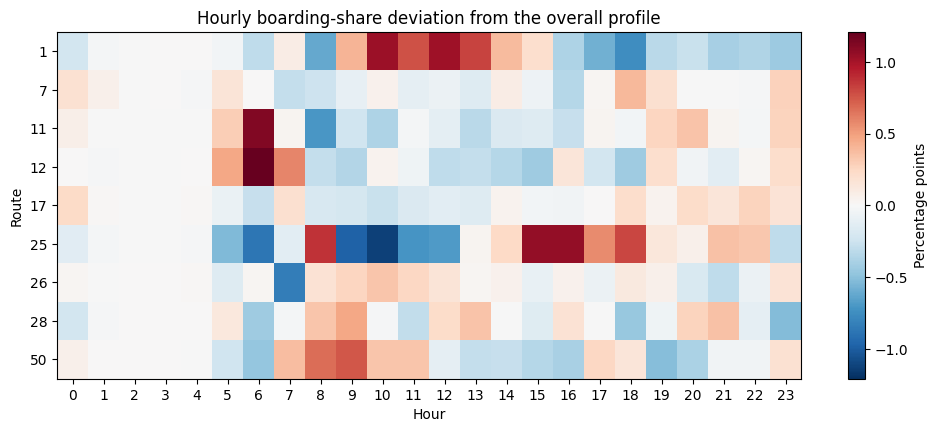

In [31]:
route_profile = shares.groupby(["route", "hour"])["share"].mean().unstack("hour")
overall_profile = shares.groupby("hour")["share"].mean()
route_delta_pp = route_profile.sub(overall_profile, axis="columns") * 100
route_distance_pp = route_delta_pp.abs().sum(axis=1) / 2
print(f"Mean route-to-overall profile distance: {route_distance_pp.mean():.2f} pp")
print(f"Range across routes: {route_distance_pp.min():.2f}–{route_distance_pp.max():.2f} pp")

fig, ax = plt.subplots(figsize=(12, 4.5))
heatmap_data = route_delta_pp.to_numpy(dtype=float)
limit = max(np.nanmax(np.abs(heatmap_data)), 0.01)
heatmap = ax.imshow(heatmap_data, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(route_profile)), labels=route_profile.index)
ax.set_xlabel("Hour")
ax.set_ylabel("Route")
ax.set_title("Hourly boarding-share deviation from the overall profile")
fig.colorbar(heatmap, ax=ax, label="Percentage points")
plt.show()

### `hour × weekend`

Средние часовые доли по всем дням маршрутов, отдельно для будней и выходных. Метрика расстояния полной вариации суммирует перераспределение суточной доли между часами; максимум абсолютного разрыва показывает самый различающийся час.

Route-days: weekdays 1557, weekends 630
Distance between profiles: 13.37 pp
Largest hourly gap: 4.87 pp at 08:00


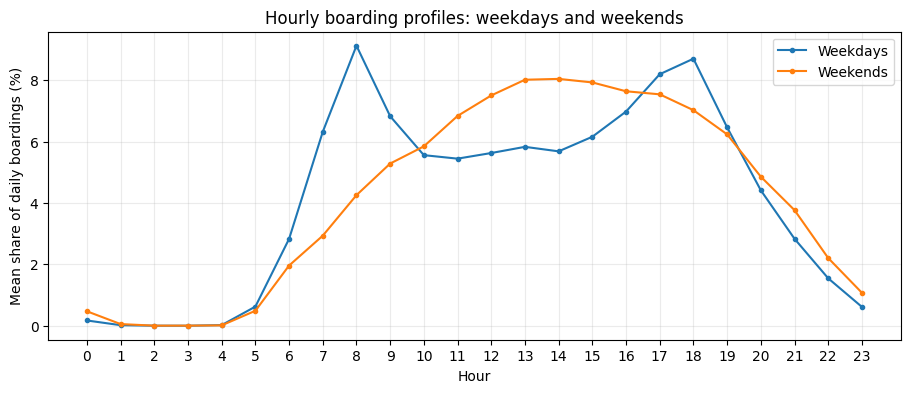

In [32]:
day_type_counts = (
    shares[["route", "date", "is_weekend"]].drop_duplicates()
    .groupby("is_weekend").size()
)
day_profile = shares.groupby(["is_weekend", "hour"])["share"].mean().unstack("hour")
assert {False, True}.issubset(day_profile.index), "Both weekdays and weekends are required"
gap_pp = (day_profile.loc[True] - day_profile.loc[False]) * 100
print(f"Route-days: weekdays {day_type_counts[False]}, weekends {day_type_counts[True]}")
print(f"Distance between profiles: {gap_pp.abs().sum() / 2:.2f} pp")
print(f"Largest hourly gap: {gap_pp.abs().max():.2f} pp at {gap_pp.abs().idxmax():02d}:00")

fig, ax = plt.subplots(figsize=(11, 4))
for is_weekend, label in [(False, "Weekdays"), (True, "Weekends")]:
    ax.plot(day_profile.columns, day_profile.loc[is_weekend] * 100, marker="o", ms=3, label=label)
ax.set_xticks(range(24))
ax.set_xlabel("Hour")
ax.set_ylabel("Mean share of daily boardings (%)")
ax.set_title("Hourly boarding profiles: weekdays and weekends")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Conclusion

На 9 маршрутах и 243 днях (январь–август 2025; 0 дней маршрута исключено как полностью нулевые) суточные профили различаются. Среднее расстояние профиля маршрута от общего составило 2.85 п.п. и лежало в диапазоне 1.43–5.51 п.п. Различие профилей будней и выходных составило 13.37 п.п.; наибольший почасовой разрыв — 4.87 п.п. в 08:00. Эти результаты поддерживают наличие различий, описываемых взаимодействиями `route × hour` и `hour × weekend`.

### Decision

Оставить оба взаимодействия кандидатами для следующего сравнения признаков. Эти агрегированные профили сами по себе не показывают, улучшат ли взаимодействия точность прогноза; это потребует отдельной временной валидации модели.

## Feature experiment — interaction features

Сравниваем четыре варианта одной и той же модели LightGBM: текущий baseline, добавление `route × hour`, добавление `hour × weekend` и добавление обоих признаков. Во всех вариантах сохраняются baseline-признаки `route`, `weekday`, `hour`, параметры модели, seed, округление прогноза и временное разделение: обучение на январе–августе 2025, проверка на сентябре–октябре 2025.

Каждое взаимодействие кодируется отдельным категориальным признаком с фиксированным словарём категорий для train и validation. Для загрузки используются пути из `Environment & Data Setup`; CSV читаются с разделителем `;`, как в `lightgbm_baseline.py`. Фактические `boardings` валидации читаются только после получения всех прогнозов.

WAPE и `delta_WAPE_vs_baseline` выводятся как доли; отрицательная дельта означает меньшую ошибку. WAPE маршрута с нулевой суммой фактических посадок не определён и отображается как `NaN`.

In [33]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
BASELINE_FEATURES = ("route", "weekday", "hour")
EXPERIMENTS = (
    ("baseline", ()),
    ("route_hour", ("route_hour",)),
    ("hour_weekend", ("hour_weekend",)),
    ("both", ("route_hour", "hour_weekend")),
)

train = pd.read_csv(TRAIN_HOURLY_PATH, sep=";", parse_dates=["date"])
validation_keys = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["route", "date", "hour"], parse_dates=["date"]
)
if len(train) != 58_320 or len(validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if train["date"].max() >= validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def calendar_features(rows, added_features=()):
    features = pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )
    if "route_hour" in added_features:
        features["route_hour"] = pd.Categorical(
            rows["route"] * 24 + rows["hour"],
            categories=[route * 24 + hour for route in ROUTES for hour in range(24)],
        )
    if "hour_weekend" in added_features:
        features["hour_weekend"] = pd.Categorical(
            rows["hour"] * 2 + rows["date"].dt.weekday.ge(5).astype(int),
            categories=range(48),
        )
    return features.loc[:, list(BASELINE_FEATURES + added_features)]

In [34]:
predictions_by_experiment = {}
for experiment, added_features in EXPERIMENTS:
    feature_columns = BASELINE_FEATURES + added_features
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        calendar_features(train, added_features),
        train["boardings"],
        categorical_feature=list(feature_columns),
    )
    prediction = np.floor(
        np.maximum(model.predict(calendar_features(validation_keys, added_features)), 0) + 0.5
    )
    predictions_by_experiment[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

baseline: 14,640 validation predictions
route_hour: 14,640 validation predictions
hour_weekend: 14,640 validation predictions
both: 14,640 validation predictions


In [35]:
actual = pd.read_csv(VALID_HOURLY_PATH, sep=";", usecols=["boardings"])["boardings"].to_numpy()
if len(actual) != len(validation_keys) or actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(actual) or not np.isfinite(prediction).all()
    for prediction in predictions_by_experiment.values()
):
    raise ValueError("Invalid validation predictions")

summary_rows = []
route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
for experiment, added_features in EXPERIMENTS:
    absolute_error = np.abs(actual - predictions_by_experiment[experiment])
    summary_rows.append(
        {
            "experiment": experiment,
            "added_features": ", ".join(added_features) or "none",
            "WAPE": absolute_error.sum() / actual.sum(),
        }
    )
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_wape[experiment] = route_error / route_totals.replace(0, np.nan)

summary = pd.DataFrame(summary_rows)
baseline_wape = summary.loc[summary["experiment"].eq("baseline"), "WAPE"].iloc[0]
summary["delta_WAPE_vs_baseline"] = summary["WAPE"] - baseline_wape
print("Overall validation WAPE:")
display(summary.round(6))
print("WAPE by route (NaN means zero actual boardings):")
display(route_wape.reset_index().round(6))

Overall validation WAPE:


,experiment,added_features,WAPE,delta_WAPE_vs_baseline
0,baseline,none,0.132223,0.000000
1,route_hour,route_hour,0.127852,-0.004371
2,hour_weekend,hour_weekend,0.125233,-0.006990
3,both,"route_hour, hour_weekend",0.124226,-0.007997


WAPE by route (NaN means zero actual boardings):


,route,baseline,route_hour,hour_weekend,both
0,1,0.115082,0.117248,0.109434,0.109786
1,5,NaN,NaN,NaN,NaN
2,7,0.154506,0.154659,0.155729,0.157241
3,11,0.112404,0.108857,0.106732,0.106466
4,12,0.093846,0.092277,0.091424,0.088752
5,17,0.108239,0.090779,0.085868,0.086480
6,25,0.198486,0.203074,0.196006,0.198600
7,26,0.126216,0.131421,0.124021,0.127367
8,28,0.154428,0.159331,0.155350,0.154626
9,50,0.246597,0.247151,0.245962,0.240818


### Conclusion

На validation holdout overall WAPE baseline составил 0.132223. Все три варианта с interaction features дали меньший overall WAPE: `route_hour` — 0.127852 (дельта −0.004371, или −0.4371 п.п.), `hour_weekend` — 0.125233 (−0.006990, или −0.6990 п.п.), `both` — 0.124226 (−0.007997, или −0.7997 п.п.). `both` показал наименьший overall WAPE.

По сравнению с baseline WAPE улучшился на 3 из 9 маршрутов у `route_hour`, на 7 из 9 у `hour_weekend` и на 5 из 9 у `both`. У `both` ухудшение осталось на маршрутах 7, 25, 26 и 28; у `hour_weekend` — на маршрутах 7 и 28. Для маршрута 5 WAPE не определён из-за нулевой суммы фактических посадок.

### Decision

| Вариант | Решение | Основание по outputs |
|---|---|---|
| `baseline` | **KEEP** | Текущий вариант; reference WAPE = 0.132223. |
| `route_hour` | **INCONCLUSIVE** | Overall WAPE ниже baseline, но улучшение есть только на 3 из 9 маршрутов с определённым WAPE. |
| `hour_weekend` | **KEEP** | Overall WAPE ниже на 0.006990; WAPE улучшился на 7 из 9 маршрутов с определённым WAPE. |
| `both` | **KEEP** | Лучший overall WAPE (0.124226), хотя WAPE улучшился только на 5 и ухудшился на 4 из 9 маршрутов с определённым WAPE. Решение ориентировано на overall WAPE. |

Оценка относится к этому holdout; в outputs нет повторных временных срезов или оценки разброса метрик.

## Feature experiment roadmap

Инвентаризация всех кандидатов из `data/Features.md`. Статусы и результат H2 взяты из сохранённых outputs текущего notebook. Значения известны для Nov–Dec, если детерминированы ключами prediction grid или сформированы из источника, опубликованного до inference.

### A. Безопасные / известные заранее

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `route`, `hour`, `dow`: задают базовые различия маршрута, часа и дня недели | `route/date/hour` из grid → да | Нет; не требуется | Календарь/время, известные заранее | **KEEP** — frozen baseline | Эталон |
| `month`: сезонный дрейф | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H3, WAPE 0.215877 против 0.124226 у принятой модели; хуже на 9/9 маршрутов | Проверено в H3 |
| `day`, `weekofyear`: внутримесячная и сезонная динамика | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **NOT_TESTED** | 1: сначала day, затем weekofyear |
| `is_weekend`: профиль выходных отличается | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **SIGNAL_CHECKED**: weekend-профиль отличается; самостоятельное влияние на модель не тестировался | 2, только отдельно от уже проверенного взаимодействия |
| `is_night`, `is_peak`: ночной и пиковый часы образуют отдельные режимы | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **NOT_TESTED** | 2 |
| `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos`: циклическое кодирование сближает соседние границы цикла | `hour/date` → да | Нет; не требуется | Календарь/время, известные заранее | **NOT_TESTED** | 3, после raw calendar |
| `hour_weekend` (`hour × weekend`): суточный профиль зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: WAPE 0.125233, Δ −0.006990; лучше baseline на 7/9 маршрутов с определённым WAPE | Уже проверено |
| `hour_weekend_sin/cos`: циклический профиль выходного часа | `hour/date` → да | Нет; не требуется | Взаимодействие | **NOT_TESTED** — это иное кодирование, чем проверенный категориальный `hour_weekend` | 4 |
| `peak_weekday`, `peak_weekend`: пик зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **NOT_TESTED** | 4, после проверки `is_peak) |
| `route_hour` (`route × hour`): у маршрутов разные суточные профили | `route/hour` → да; для route 5 значение строится, но нет положительной истории для обучения его профиля | Нет; не требуется. У route 5 есть cold-start риск, не leakage | Взаимодействие | **INCONCLUSIVE** — проверено моделью: WAPE 0.127852, Δ −0.004371; лучше baseline на 3/9 маршрутов | 1: разрешить неопределённость на дополнительных temporal cutoffs |
| `route_hour_sin/cos`: циклическое кодирование route-specific профиля | `route/hour` + фиксированный `route_idx` mapping → да; route 5 остаётся cold start | Нет; не требуется. Порядок route_idx искусственный и требует проверки | Взаимодействие | **NOT_TESTED** | 5 |
| `route_dow`: реакция на день недели различается по маршрутам | `route/date` → да; route 5 остаётся cold start | Нет; не требуется | Взаимодействие | **NOT_TESTED** | 5 |
| `route_hour + hour_weekend`: совместно описывают маршрутный и недельный профили | `route/hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: лучший overall WAPE 0.124226, Δ −0.007997; лучше baseline на 5/9 маршрутов | Уже проверено; учитывать ухудшение на маршрутах 7, 25, 26, 28 |
| `days_since_start`: отражает временной дрейф | `date` и фиксированная start date → да | Нет; не требуется. Риск — экстраполяция дерева за диапазон train | Календарь/время, известные заранее (trend) | **NOT_TESTED** | 6, последним среди safe candidates |

Проверка сигнала H2 в notebook: расстояние между weekend/weekday профилями — 13.37 п.п.; максимальный почасовой разрыв — 4.87 п.п. в 08:00. Это описательный сигнал; статусы проверено моделью выше опираются на отдельный контролируемый эксперимент.

### B. Исторические / производные от target

В `data/Features.md` пока нет конкретных гипотез для исторических агрегатов или лагов и скользящих агрегатов от target. EDA и контекст прогнозирования упоминают лаги/агрегаты, но это ещё не зарегистрированные кандидаты. Перед проверкой нужно определить окно и способ построения. Источник — прошлые `boardings`; leakage возникает при использовании фактического target validation или будущего периода или глобальных агрегатов. Для validation и Nov–Dec требуется open-loop оценка: лаги/окна, попадающие внутрь прогнозного горизонта, рассчитывать рекурсивно по предыдущим predictions. Порядок — после safe calendar candidates и регистрации точной гипотезы в Features.md.

### C. Внешние / пока недоступные

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `is_holiday`: праздники объясняют часть провалов пассажиропотока | Официальный календарь праздников + `date` → будет известно заранее, если календарь подтверждён до inference; такого источника в текущем setup не найдено | Нет при заранее зафиксированном календаре; leakage, если метки выводить из наблюдаемого target постфактум. Open-loop не требуется | Внешние метаданные + known-in-advance calendar/time | **BLOCKED** до предоставления/подтверждения календаря | После подтверждения источника |

EDA также упоминает погоду и заранее известные изменения движения, но таких feature-кандидатов пока нет в `data/Features.md`; они не включены в эту инвентаризацию.

## H3 — month

### Hypothesis

Числовой календарный месяц может отражать медленные изменения пассажиропотока сверх принятого набора признаков `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только `date.month`.

### Availability / leakage

Месяц известен из ключа `(route, date, hour)` для всего периода Nov–Dec. Не нужны будущий target, внешние данные или рекурсия. Train охватывает январь–август, validation — сентябрь–октябрь, а inference — ноябрь–декабрь. Значения месяца на validation и inference выходят за диапазон train. Дерево LightGBM не экстраполирует тренд за обученные пороги; по одному году нельзя установить повторяющуюся годовую сезонность.


### Analysis

Используются только данные train за январь–август. Сравниваются помесячные средние посадок и средние остатки после учёта `route`, `weekday` и `hour`. Остаток служит только для описательной проверки и не становится признаком модели.


In [36]:
month_analysis = train[["route", "date", "hour", "boardings"]].copy()
month_analysis["month"] = month_analysis["date"].dt.month
month_analysis["weekday"] = month_analysis["date"].dt.weekday
context_mean = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
month_analysis["context_residual"] = month_analysis["boardings"] - context_mean
monthly_signal = month_analysis.groupby("month").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only monthly signal:")
display(monthly_signal.round(3))
print(
    "Range of monthly context residual means:",
    round(monthly_signal["mean_context_residual"].max()
          - monthly_signal["mean_context_residual"].min(), 3),
)


Training-only monthly signal:


,observations,mean_boardings,mean_context_residual
month,,,
1,7440,748.296,-66.877
2,6720,883.151,77.743
3,7440,903.048,111.787
4,7200,891.441,77.497
5,7440,806.575,2.846
6,7200,771.526,-27.079
7,7440,726.838,-90.084
8,7440,713.707,-76.682


Range of monthly context residual means: 201.871


### Correlation / redundancy

Для числового `month` рассчитываются Pearson и Spearman с target и описательным остатком. Число месяцев внутри каждого сочетания `route/weekday/hour` показывает структурную избыточность. Pearson для кодов категориальных признаков здесь неинформативен. Корреляция сама по себе не определяет решение о включении признака.


In [37]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"month vs {target_name}",
        "Pearson": month_analysis["month"].corr(month_analysis[target_name], method="pearson"),
        "Spearman": month_analysis["month"].corr(month_analysis[target_name], method="spearman"),
    })
print("Numeric month diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
months_per_context = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["month"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple months:",
    f"{months_per_context.gt(1).sum()} / {len(months_per_context)}",
)


Numeric month diagnostics on training data:


,pair,Pearson,Spearman
0,month vs boardings,-0.0428,-0.0217
1,month vs context_residual,-0.1382,-0.2178


Route/weekday/hour contexts observed in multiple months: 1680 / 1680


### LightGBM experiment

Сравниваются принятый набор и тот же набор с числовым `month`. Сохраняются frozen модель, гиперпараметры, обработка категориальных признаков, temporal split январь–август / сентябрь–октябрь, seed и постобработка прогнозов. Сначала нужно выполнить ячейки `Environment & Data Setup`, frozen baseline и setup H2. Фактический target validation читается только после построения обоих прогнозов.


In [38]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
MONTH_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_month", True),
)

def month_experiment_features(rows, add_month):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_month:
        features["month"] = rows["date"].dt.month.to_numpy(dtype="int16")
    return features

month_models = {}
month_predictions = {}
for experiment, add_month in MONTH_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        month_experiment_features(train, add_month),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(month_experiment_features(validation_keys, add_month)), 0
        ) + 0.5
    )
    month_models[experiment] = model
    month_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_month: 14,640 validation predictions


### Feature importance

Gain importance показывает, как модель с кандидатом использовала `month`. Сам по себе этот показатель не является основанием оставить признак.


In [39]:
candidate_model = month_models["current_accepted_plus_month"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("month")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:


,feature,gain,rank
3,month,68012.987,4


Top features by gain:


,feature,gain,rank
0,route_hour,2385372.568,1
1,route,561267.100,2
2,hour_weekend,526923.327,3
3,month,68012.987,4
4,weekday,29453.828,5


### Results

Для WAPE меньшее значение лучше, для WAPE-score — большее. Абсолютная и относительная дельты WAPE рассчитаны относительно текущего принятого набора; отдельная дельта — относительно исходного frozen baseline. Отрицательная дельта WAPE означает улучшение. WAPE маршрута не определён, если сумма его фактических посадок равна нулю.


In [40]:
month_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(month_actual) != len(validation_keys) or month_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(month_actual) or not np.isfinite(prediction).all()
    for prediction in month_predictions.values()
):
    raise ValueError("Invalid validation predictions")

month_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": month_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
month_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
month_result_rows = []
for experiment, add_month in MONTH_EXPERIMENTS:
    absolute_error = np.abs(month_actual - month_predictions[experiment])
    overall_wape = absolute_error.sum() / month_actual.sum()
    month_result_rows.append({
        "experiment": experiment,
        "added_features": "month" if add_month else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    month_route_wape[experiment] = route_error / month_route_totals.replace(0, np.nan)

month_results = pd.DataFrame(month_result_rows)
accepted_wape = month_results.loc[
    month_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
month_results["delta_WAPE_vs_accepted"] = month_results["WAPE"] - accepted_wape
month_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * month_results["delta_WAPE_vs_accepted"] / accepted_wape
)
month_results["delta_WAPE_vs_frozen_baseline"] = (
    month_results["WAPE"] - frozen_overall_wape
)
month_route_wape["delta_month_vs_accepted"] = (
    month_route_wape["current_accepted_plus_month"]
    - month_route_wape["current_accepted"]
)
print("Overall validation results:")
display(month_results.round(6))
print("Validation WAPE by route:")
display(month_route_wape.reset_index().round(6))


Overall validation results:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124226,0.875774,0.000000,0.000000,-0.007997
1,current_accepted_plus_month,month,0.215877,0.784123,0.091652,73.778238,0.083654


Validation WAPE by route:


,route,current_accepted,current_accepted_plus_month,delta_month_vs_accepted
0,1,0.109786,0.201230,0.091444
1,5,NaN,NaN,NaN
2,7,0.157241,0.374690,0.217449
3,11,0.106466,0.170118,0.063652
4,12,0.088752,0.150549,0.061797
5,17,0.086480,0.144884,0.058404
6,25,0.198600,0.312836,0.114236
7,26,0.127367,0.260424,0.133057
8,28,0.154626,0.271345,0.116719
9,50,0.240818,0.309860,0.069042


### Conclusion

На temporal holdout за сентябрь–октябрь добавление числового `month` увеличило overall WAPE с 0.124226 до 0.215877: абсолютная дельта +0.091652, относительная +73.78%. WAPE-score снизился с 0.875774 до 0.784123. Результат кандидата выше исходного frozen baseline по WAPE на +0.083654. WAPE ухудшился на всех 9 маршрутах с определённой метрикой; для маршрута 5 знаменатель равен нулю.

На train средние помесячные остатки после учёта `route`, `weekday` и `hour` различались в диапазоне 201.871, а месяц менялся внутри всех 1680 таких сочетаний. Корреляции Pearson/Spearman с посадками были слабыми (−0.0428/−0.0217), с описательным остатком — умеренными (−0.1382/−0.2178). Gain importance составила 68012.987 (ранг 4): модель использовала признак, но качество на validation ухудшилось. Месяцы сентября–октября находились вне диапазона train, поэтому вывод относится к этому числовому кодированию и holdout.

### Decision

**REJECT** для числового `month`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `month` в него не добавляется.


## H4 — day

### Hypothesis

Числовой день месяца (`date.day`, 1–31) может отражать повторяющийся внутримесячный профиль спроса сверх принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только этот кандидат.

### Availability / leakage

День месяца известен из даты на всём горизонте Nov–Dec. Не нужны target, внешние данные или рекурсия. Все значения дня встречаются в train за январь–август, хотя для последних дней месяца наблюдений меньше. Target validation не используется при построении признака.


### Analysis

Используются только данные train за январь–август. Для каждого дня месяца рассматриваются средние посадки и средние остатки после учёта `route`, `weekday` и `hour`, вместе с числом наблюдений. Это проверка сигнала; описательный остаток не поступает в модель.


In [ ]:
day_analysis = train[["route", "date", "hour", "boardings"]].copy()
day_analysis["day"] = day_analysis["date"].dt.day
day_analysis["weekday"] = day_analysis["date"].dt.weekday
context_mean = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
day_analysis["context_residual"] = day_analysis["boardings"] - context_mean
daily_signal = day_analysis.groupby("day").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only daily signal:")
display(daily_signal.round(3))
print(
    "Range of daily context residual means:",
    round(daily_signal["mean_context_residual"].max()
          - daily_signal["mean_context_residual"].min(), 3),
)


### Correlation / redundancy

Для числового дня рассчитываются Pearson и Spearman с посадками и описательным остатком. Дополнительно подсчитывается число разных дней внутри каждого сочетания `route/weekday/hour`. Коды категориальных признаков не трактуются как непрерывные величины. Одна корреляция не определяет, включать ли признак.


In [ ]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"day vs {target_name}",
        "Pearson": day_analysis["day"].corr(day_analysis[target_name], method="pearson"),
        "Spearman": day_analysis["day"].corr(day_analysis[target_name], method="spearman"),
    })
print("Numeric day diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
days_per_context = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["day"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple days:",
    f"{days_per_context.gt(1).sum()} / {len(days_per_context)}",
)


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой `day`. Сохраняются frozen параметры LightGBM, обработка категориальных признаков, seed, train за январь–август, holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Target holdout читается только после завершения обоих прогнозов.


In [ ]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
DAY_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_day", True),
)

def day_experiment_features(rows, add_day):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_day:
        features["day"] = rows["date"].dt.day.to_numpy(dtype="int16")
    return features

day_models = {}
day_predictions = {}
for experiment, add_day in DAY_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        day_experiment_features(train, add_day),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(day_experiment_features(validation_keys, add_day)), 0
        ) + 0.5
    )
    day_models[experiment] = model
    day_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


### Feature importance

Gain importance и ранг показывают, как модель использовала `day`; это дополнительная диагностика к temporal WAPE.


In [ ]:
candidate_model = day_models["current_accepted_plus_day"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("day")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Если сумма фактических посадок маршрута равна нулю, его WAPE не определён.


In [ ]:
day_actual = pd.read_csv(
    VALID_HOURLY_PATH, sep=";", usecols=["boardings"]
)["boardings"].to_numpy()
if len(day_actual) != len(validation_keys) or day_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(day_actual) or not np.isfinite(prediction).all()
    for prediction in day_predictions.values()
):
    raise ValueError("Invalid validation predictions")

day_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": day_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
day_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
day_result_rows = []
for experiment, add_day in DAY_EXPERIMENTS:
    absolute_error = np.abs(day_actual - day_predictions[experiment])
    overall_wape = absolute_error.sum() / day_actual.sum()
    day_result_rows.append({
        "experiment": experiment,
        "added_features": "day" if add_day else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    day_route_wape[experiment] = route_error / day_route_totals.replace(0, np.nan)

day_results = pd.DataFrame(day_result_rows)
accepted_wape = day_results.loc[
    day_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
day_results["delta_WAPE_vs_accepted"] = day_results["WAPE"] - accepted_wape
day_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * day_results["delta_WAPE_vs_accepted"] / accepted_wape
)
day_results["delta_WAPE_vs_frozen_baseline"] = (
    day_results["WAPE"] - frozen_overall_wape
)
day_route_wape["delta_day_vs_accepted"] = (
    day_route_wape["current_accepted_plus_day"]
    - day_route_wape["current_accepted"]
)
print("Overall validation results:")
display(day_results.round(6))
print("Validation WAPE by route:")
display(day_route_wape.reset_index().round(6))


### Conclusion

Ожидаются выполнение ячеек в текущем Colab kernel и сохранённые фактические outputs.

### Decision

Ожидаются фактические значения overall WAPE и WAPE по маршрутам.
